# Airline Customer Holiday Booking — Milestone 1

This notebook implements a complete pipeline to analyze and model passenger satisfaction using the provided datasets:
- AirlineScrappedReview_Cleaned.csv (cleaned reviews)
- Customer_comment.csv (operational + feedback)
- Passanger_booking_data.csv (booking behavior)
- Survey data_Inflight Satisfaction Score.csv (survey responses)

We will: data clean, engineer sentiment features, answer EDA questions, build and evaluate a binary classifier, explain the model (SHAP, LIME), and provide an inference function.

In [4]:
# Setup and imports
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from pathlib import Path
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

# Plot style
sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)

# Paths (relative)
DATA_DIR = Path("data")
PATH_CUSTOMER = DATA_DIR / "Customer_comment.csv"
PATH_BOOKING = DATA_DIR / "Passanger_booking_data.csv"
PATH_SURVEY = DATA_DIR / "Survey data_Inflight Satisfaction Score.csv"
PATH_REVIEWS = DATA_DIR / "AirlineScrappedReview_Cleaned.csv"
PATH_REVIEWS_WITH_SENT = DATA_DIR / "AirlineScrappedReview_with_sentiment.csv"

In [5]:
# What are the top 10 most popular flight routes? -> route column in AirlineScrappedReview_Cleaned
# What is the distribution of bookings across flight hours? -> flight_hour in Passanger_booking_data
# By analyzing review patterns, which traveler type and class combination yields the highest and lowest ratings? -> use rating column in AirlineScrappedReview_Cleaned 

In [6]:
# Load Customer_comment with relative path
df = pd.read_csv(PATH_CUSTOMER)

# Quick glance
display(df.head())
print(df.info())
print(df.describe(include='all').T.head(20))
print("\nNulls per column:\n", df.isnull().sum().sort_values(ascending=False).head(20))

,Unnamed: 0,flight_number,origin_station_code,destination_station_code,scheduled_departure_date,arrival_delay_group,departure_delay_group,entity,verbatim_text,seat_factor_band,ques_verbatim_text,loyalty_program_level,fleet_type_description,fleet_usage,response_group,sentiments,transformed_text
0,0,950,LHX,SFX,2022-09-01,Early & Ontime,Delayed,Atlantic,There was no salad dressing. The staff informe...,0 to 70,Is there anything else you'd like to share abo...,non-elite,B777-200,Mainline,member,Neutral,salad dress staff inform flight receiv salad d...
1,1,950,LHX,SFX,2022-09-01,Early & Ontime,Delayed,Atlantic,Not a choice.,0 to 70,Is there anything else you'd like to share abo...,NaN,B777-200,Mainline,non-member,Neutral,choic
2,2,1876,FLX,EWX,2022-09-01,Early & Ontime,Early & Ontime,Domestic,More variety and bigger snacks.,90+,Is there anything else you'd like to share abo...,non-elite,A320-200,Mainline,member,Neutral,varieti bigger snack
3,3,5469,SFX,SEX,2022-09-01,Early & Ontime,Early & Ontime,Domestic,Serving pretzels and cookies in first class wa...,90+,Is there anything else you'd like to share abo...,premier gold,ERJ-175,Express,member,Neutral,serv pretzel cooki first class extrem disappoi...
4,4,281,DEX,ANX,2022-09-01,Early & Ontime,Early & Ontime,Domestic,More inflight selections to purchase for full ...,0 to 70,Is there anything else you'd like to share abo...,non-elite,B737-MAX8,Mainline,member,Neutral,inflight select purchas full meal


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9424 entries, 0 to 9423
Data columns (total 17 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Unnamed: 0                9424 non-null   int64 
 1   flight_number             9424 non-null   int64 
 2   origin_station_code       9424 non-null   object
 3   destination_station_code  9424 non-null   object
 4   scheduled_departure_date  9424 non-null   object
 5   arrival_delay_group       9424 non-null   object
 6   departure_delay_group     9424 non-null   object
 7   entity                    9424 non-null   object
 8   verbatim_text             9424 non-null   object
 9   seat_factor_band          9424 non-null   object
 10  ques_verbatim_text        9424 non-null   object
 11  loyalty_program_level     6920 non-null   object
 12  fleet_type_description    9424 non-null   object
 13  fleet_usage               9424 non-null   object
 14  response_group          

In [7]:
df.head()

,Unnamed: 0,flight_number,origin_station_code,destination_station_code,scheduled_departure_date,arrival_delay_group,departure_delay_group,entity,verbatim_text,seat_factor_band,ques_verbatim_text,loyalty_program_level,fleet_type_description,fleet_usage,response_group,sentiments,transformed_text
0,0,950,LHX,SFX,2022-09-01,Early & Ontime,Delayed,Atlantic,There was no salad dressing. The staff informe...,0 to 70,Is there anything else you'd like to share abo...,non-elite,B777-200,Mainline,member,Neutral,salad dress staff inform flight receiv salad d...
1,1,950,LHX,SFX,2022-09-01,Early & Ontime,Delayed,Atlantic,Not a choice.,0 to 70,Is there anything else you'd like to share abo...,NaN,B777-200,Mainline,non-member,Neutral,choic
2,2,1876,FLX,EWX,2022-09-01,Early & Ontime,Early & Ontime,Domestic,More variety and bigger snacks.,90+,Is there anything else you'd like to share abo...,non-elite,A320-200,Mainline,member,Neutral,varieti bigger snack
3,3,5469,SFX,SEX,2022-09-01,Early & Ontime,Early & Ontime,Domestic,Serving pretzels and cookies in first class wa...,90+,Is there anything else you'd like to share abo...,premier gold,ERJ-175,Express,member,Neutral,serv pretzel cooki first class extrem disappoi...
4,4,281,DEX,ANX,2022-09-01,Early & Ontime,Early & Ontime,Domestic,More inflight selections to purchase for full ...,0 to 70,Is there anything else you'd like to share abo...,non-elite,B737-MAX8,Mainline,member,Neutral,inflight select purchas full meal


In [8]:
df = df.dropna(subset=['transformed_text'])
df.isnull().sum()
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
Index: 8405 entries, 0 to 9423
Data columns (total 17 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Unnamed: 0                8405 non-null   int64 
 1   flight_number             8405 non-null   int64 
 2   origin_station_code       8405 non-null   object
 3   destination_station_code  8405 non-null   object
 4   scheduled_departure_date  8405 non-null   object
 5   arrival_delay_group       8405 non-null   object
 6   departure_delay_group     8405 non-null   object
 7   entity                    8405 non-null   object
 8   verbatim_text             8405 non-null   object
 9   seat_factor_band          8405 non-null   object
 10  ques_verbatim_text        8405 non-null   object
 11  loyalty_program_level     6293 non-null   object
 12  fleet_type_description    8405 non-null   object
 13  fleet_usage               8405 non-null   object
 14  response_group            840

,Unnamed: 0,flight_number
count,8405.000000,8405.000000
mean,4721.274004,1709.605830
std,2721.457634,1533.950229
min,0.000000,2.000000
25%,2359.000000,593.000000
50%,4739.000000,1258.000000
75%,7084.000000,2232.000000
max,9423.000000,6375.000000


In [9]:
print(df['loyalty_program_level'].value_counts())

print(f"\nNull values: {df['loyalty_program_level'].isnull().sum()}")

print(f"\nData type: {df['loyalty_program_level'].dtype}")

loyalty_program_level
non-elite           3674
premier silver       806
premier 1k           687
premier gold         564
premier platinum     428
global services      133
NBK                    1
Name: count, dtype: int64

Null values: 2112

Data type: object


In [10]:
df['loyalty_program_level'] = df['loyalty_program_level'].fillna('None')
df.isnull().sum()

Unnamed: 0                  0
flight_number               0
origin_station_code         0
destination_station_code    0
scheduled_departure_date    0
arrival_delay_group         0
departure_delay_group       0
entity                      0
verbatim_text               0
seat_factor_band            0
ques_verbatim_text          0
loyalty_program_level       0
fleet_type_description      0
fleet_usage                 0
response_group              0
sentiments                  0
transformed_text            0
dtype: int64

In [11]:
df['departure_delay_group'] = df['departure_delay_group'].map({'Delayed': 0, 'Early & Ontime': 1})

print(df['departure_delay_group'].value_counts())

print(f"\nNull values: {df['departure_delay_group'].isnull().sum()}")

print(f"\nData type: {df['departure_delay_group'].dtype}")

departure_delay_group
1    5517
0    2888
Name: count, dtype: int64

Null values: 0

Data type: int64


In [12]:
print(df['entity'].value_counts())

print(f"\nNull values: {df['entity'].isnull().sum()}")

print(f"\nData type: {df['entity'].dtype}")

entity
Domestic    5808
Atlantic    1776
Latin        577
Pacific      244
Name: count, dtype: int64

Null values: 0

Data type: object


In [13]:
print(df['seat_factor_band'].value_counts())

print(f"\nNull values: {df['seat_factor_band'].isnull().sum()}")

print(f"\nData type: {df['seat_factor_band'].dtype}")

seat_factor_band
90+        5587
80+        1482
70+         700
0 to 70     636
Name: count, dtype: int64

Null values: 0

Data type: object


In [14]:
print(df['fleet_usage'].value_counts())

print(f"\nNull values: {df['fleet_usage'].isnull().sum()}")

print(f"\nData type: {df['fleet_usage'].dtype}")

fleet_usage
Mainline    7176
Express     1229
Name: count, dtype: int64

Null values: 0

Data type: object


In [15]:
df = df[df['response_group'] != 'NBK']



In [16]:
df['response_group'] = df['response_group'].map({'non-member': 0, 'member': 1})

In [17]:
print(df['response_group'].value_counts())
print(f"\nTotal rows remaining: {len(df)}")
print(df['response_group'].value_counts())

print(f"\nNull values: {df['response_group'].isnull().sum()}")

print(f"\nData type: {df['response_group'].dtype}")

response_group
1    6278
0    2126
Name: count, dtype: int64

Total rows remaining: 8404
response_group
1    6278
0    2126
Name: count, dtype: int64

Null values: 0

Data type: int64


In [18]:
df['sentiments'] = df['sentiments'].map({'Neutral': 0, 'Negative': 1})

print(df['sentiments'].value_counts())

print(f"\nNull values: {df['sentiments'].isnull().sum()}")

print(f"\nData type: {df['sentiments'].dtype}")

sentiments
0    8292
1     112
Name: count, dtype: int64

Null values: 0

Data type: int64


In [19]:
df['fleet_usage'] = df['fleet_usage'].map({'Mainline': 0, 'Express': 1})
print(df['fleet_usage'].value_counts())

print(f"\nNull values: {df['fleet_usage'].isnull().sum()}")

print(f"\nData type: {df['fleet_usage'].dtype}")

fleet_usage
0    7176
1    1228
Name: count, dtype: int64

Null values: 0

Data type: int64


In [20]:
# Load booking data with relative path
df2 = pd.read_csv(PATH_BOOKING)

# Quick glance
display(df2.head())
print(df2.info())
print(df2.describe(include='all').T.head(20))
print("\nNulls per column:\n", df2.isnull().sum().sort_values(ascending=False).head(20))

,num_passengers,sales_channel,trip_type,purchase_lead,length_of_stay,flight_hour,flight_day,route,booking_origin,wants_extra_baggage,wants_preferred_seat,wants_in_flight_meals,flight_duration,booking_complete
0,1,Internet,RoundTrip,21,12,6,Tue,AKLHGH,Australia,0,0,0,7.21,1
1,2,Internet,RoundTrip,262,19,7,Sat,AKLDEL,New Zealand,1,0,0,5.52,0
2,1,Internet,RoundTrip,112,20,3,Sat,AKLDEL,New Zealand,0,0,0,5.52,0
3,2,Internet,RoundTrip,243,22,17,Wed,AKLDEL,India,1,1,0,5.52,0
4,1,Internet,RoundTrip,96,31,4,Sat,AKLDEL,New Zealand,0,0,1,5.52,0


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50002 entries, 0 to 50001
Data columns (total 14 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   num_passengers         50002 non-null  int64  
 1   sales_channel          50002 non-null  object 
 2   trip_type              50002 non-null  object 
 3   purchase_lead          50002 non-null  int64  
 4   length_of_stay         50002 non-null  int64  
 5   flight_hour            50002 non-null  int64  
 6   flight_day             50002 non-null  object 
 7   route                  50002 non-null  object 
 8   booking_origin         50002 non-null  object 
 9   wants_extra_baggage    50002 non-null  int64  
 10  wants_preferred_seat   50002 non-null  int64  
 11  wants_in_flight_meals  50002 non-null  int64  
 12  flight_duration        50002 non-null  float64
 13  booking_complete       50002 non-null  int64  
dtypes: float64(1), int64(8), object(5)
memory usage: 5.3+ 

                         count unique        top   freq       mean        std  \
num_passengers         50002.0    NaN        NaN    NaN   1.591256   1.020167   
sales_channel            50002      2   Internet  44383        NaN        NaN   
trip_type                50002      3  RoundTrip  49498        NaN        NaN   
purchase_lead          50002.0    NaN        NaN    NaN  84.940582  90.450548   
length_of_stay         50002.0    NaN        NaN    NaN  23.044778  33.887171   
flight_hour            50002.0    NaN        NaN    NaN   9.066277   5.412569   
flight_day               50002      7        Mon   8102        NaN        NaN   
route                    50002    799     AKLKUL   2680        NaN        NaN   
booking_origin           50002    104  Australia  17873        NaN        NaN   
wants_extra_baggage    50002.0    NaN        NaN    NaN   0.668773   0.470659   
wants_preferred_seat   50002.0    NaN        NaN    NaN   0.296968   0.456927   
wants_in_flight_meals  50002

In [21]:
display(df2.head())

,num_passengers,sales_channel,trip_type,purchase_lead,length_of_stay,flight_hour,flight_day,route,booking_origin,wants_extra_baggage,wants_preferred_seat,wants_in_flight_meals,flight_duration,booking_complete
0,1,Internet,RoundTrip,21,12,6,Tue,AKLHGH,Australia,0,0,0,7.21,1
1,2,Internet,RoundTrip,262,19,7,Sat,AKLDEL,New Zealand,1,0,0,5.52,0
2,1,Internet,RoundTrip,112,20,3,Sat,AKLDEL,New Zealand,0,0,0,5.52,0
3,2,Internet,RoundTrip,243,22,17,Wed,AKLDEL,India,1,1,0,5.52,0
4,1,Internet,RoundTrip,96,31,4,Sat,AKLDEL,New Zealand,0,0,1,5.52,0


In [22]:
df2['sales_channel'] = df2['sales_channel'].map({'Internet': 0, 'Mobile': 1})

print(df2['sales_channel'].value_counts())

print(f"\nNull values: {df2['sales_channel'].isnull().sum()}")


print(f"\nData type: {df2['sales_channel'].dtype}")

sales_channel
0    44383
1     5619
Name: count, dtype: int64

Null values: 0

Data type: int64


In [23]:
print(df2['trip_type'].value_counts())

print(f"\nNull values: {df2['trip_type'].isnull().sum()}")

print(f"\nData type: {df2['trip_type'].dtype}")

trip_type
RoundTrip     49498
OneWay          387
CircleTrip      117
Name: count, dtype: int64

Null values: 0

Data type: object


In [24]:
# Load survey data with relative path
df3 = pd.read_csv(PATH_SURVEY)

# Quick glance
display(df3.head())
print(df3.info())
print(df3.describe(include='all').T.head(20))
print("\nNulls per column:\n", df3.isnull().sum().sort_values(ascending=False).head(20))

,flight_number,origin_station_code,destination_station_code,record_locator,scheduled_departure_date,question_text,score,satisfaction_type,driver_sub_group1,driver_sub_group2,...,equipment_type_code,ua_uax,actual_flown_miles,haul_type,departure_gate,arrival_gate,international_domestic_indicator,response_group,media_provider,hub_spoke
0,3802,MKX,ORX,CYXXJJ,9/1/2022,How satisfied were you with the food & beverag...,2,Dissatisfied,food & beverage,food and beverage satisfaction,...,CRZ,UAX,67,Short,C12,F10,Domestic,non-member,NaN,spoke departure
1,4645,COX,DEX,DRXXMH,9/1/2022,How satisfied were you with the food & beverag...,5,Satisfied,food & beverage,food and beverage satisfaction,...,E75,UAX,72,Short,5,B60,Domestic,member,GOGO,spoke departure
2,5236,COX,DEX,DEXXS1,9/1/2022,How satisfied were you with the food & beverag...,5,Satisfied,food & beverage,food and beverage satisfaction,...,E75,UAX,72,Short,7,A71,Domestic,member,GOGO,spoke departure
3,4686,DEX,COX,PXXXLH,9/1/2022,How satisfied were you with the food & beverag...,3,Dissatisfied,food & beverage,food and beverage satisfaction,...,CRJ,UAX,72,Short,B82,5,Domestic,member,NaN,hub departure
4,671,DEX,COX,KZXXH5,9/1/2022,How satisfied were you with the food & beverag...,5,Satisfied,food & beverage,food and beverage satisfaction,...,19F,UA,72,Short,B24,3,Domestic,member,PANASONIC,hub departure


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 47074 entries, 0 to 47073
Data columns (total 31 columns):
 #   Column                            Non-Null Count  Dtype 
---  ------                            --------------  ----- 
 0   flight_number                     47074 non-null  int64 
 1   origin_station_code               47074 non-null  object
 2   destination_station_code          47074 non-null  object
 3   record_locator                    47074 non-null  object
 4   scheduled_departure_date          47074 non-null  object
 5   question_text                     47074 non-null  object
 6   score                             47074 non-null  object
 7   satisfaction_type                 34963 non-null  object
 8   driver_sub_group1                 47074 non-null  object
 9   driver_sub_group2                 47074 non-null  object
 10  arrival_delay_minutes             47074 non-null  int64 
 11  arrival_delay_group               47074 non-null  object
 12  cabin_code_desc   

In [25]:
df3.head

<bound method NDFrame.head of        flight_number origin_station_code destination_station_code  \
0               3802                 MKX                      ORX   
1               4645                 COX                      DEX   
2               5236                 COX                      DEX   
3               4686                 DEX                      COX   
4                671                 DEX                      COX   
...              ...                 ...                      ...   
47069              2                 SFX                      SIX   
47070              2                 SFX                      SIX   
47071              3                 SIX                      SFX   
47072              3                 SIX                      SFX   
47073              2                 SFX                      SIX   

      record_locator scheduled_departure_date  \
0             CYXXJJ                 9/1/2022   
1             DRXXMH                 9/1/20

In [26]:
df3['satisfaction_type'] = df3['satisfaction_type'].map({'Dissatisfied': 0, 'Satisfied': 1})

print(df3['satisfaction_type'].value_counts())

print(f"\nNull values: {df3['satisfaction_type'].isnull().sum()}")

print(f"\nData type: {df3['satisfaction_type'].dtype}")

satisfaction_type
0.0    22353
1.0    12610
Name: count, dtype: int64

Null values: 12111

Data type: float64


In [27]:
df3['international_domestic_indicator'] = df3['international_domestic_indicator'].map({'Domestic': 0, 'International': 1})

print(df3['international_domestic_indicator'].value_counts())

print(f"\nNull values: {df3['international_domestic_indicator'].isnull().sum()}")

print(f"\nData type: {df3['international_domestic_indicator'].dtype}")

international_domestic_indicator
0    29242
1    17832
Name: count, dtype: int64

Null values: 0

Data type: int64


In [28]:
print(df3['response_group'].value_counts())

print(f"\nNull values: {df3['response_group'].isnull().sum()}")

print(f"\nData type: {df3['response_group'].dtype}")

response_group
member        35382
non-member    11689
NBK               3
Name: count, dtype: int64

Null values: 0

Data type: object


In [29]:
most_common = df3['media_provider'].mode()[0]

print(f"Most common category: {most_common}\n")

df3['media_provider'].fillna(most_common, inplace=True)

Most common category: PANASONIC



C:\Users\marwa\AppData\Local\Temp\ipykernel_2028\1811113991.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df3['media_provider'].fillna(most_common, inplace=True)


In [30]:
print(df3['media_provider'].value_counts())

print(f"\nNull values: {df3['media_provider'].isnull().sum()}")

print(f"\nData type: {df3['media_provider'].dtype}")

media_provider
PANASONIC    26518
THALES       12765
GOGO          3907
VIASAT        3884
Name: count, dtype: int64

Null values: 0

Data type: object


In [31]:
print(df3['hub_spoke'].value_counts())

print(f"\nNull values: {df3['hub_spoke'].isnull().sum()}")

print(f"\nData type: {df3['hub_spoke'].dtype}")

hub_spoke
hub departure      24343
spoke departure    22731
Name: count, dtype: int64

Null values: 0

Data type: object


In [32]:
df3.drop(columns=['cabin_name'], inplace=True)

In [33]:
null_loyalty = df3[df3['loyalty_program_level'].isna()]

print(null_loyalty.shape[0])

print(null_loyalty['response_group'].value_counts())

all_non_member = null_loyalty['response_group'].eq('non-member').all()

print(all_non_member)

11616
response_group
non-member    11616
Name: count, dtype: int64
True


In [34]:
df3['loyalty_program_level'] = df3['loyalty_program_level'].fillna('None')
df3.isnull().sum()

flight_number                           0
origin_station_code                     0
destination_station_code                0
record_locator                          0
scheduled_departure_date                0
question_text                           0
score                                   0
satisfaction_type                   12111
driver_sub_group1                       0
driver_sub_group2                       0
arrival_delay_minutes                   0
arrival_delay_group                     0
cabin_code_desc                         0
entity                                  3
number_of_legs                          0
seat_factor_band                        0
loyalty_program_level                   0
generation                              0
fleet_type_description                  0
fleet_usage                             0
equipment_type_code                     0
ua_uax                                  0
actual_flown_miles                      0
haul_type                         

In [35]:
print(df3['loyalty_program_level'].value_counts())

print(f"\nNull values: {df3['loyalty_program_level'].isnull().sum()}")

print(f"\nData type: {df3['loyalty_program_level'].dtype}")

loyalty_program_level
non-elite           19331
None                11616
premier silver       4857
premier 1k           4334
premier gold         3362
premier platinum     2637
global services       934
NBK                     3
Name: count, dtype: int64

Null values: 0

Data type: object


In [36]:
df3.drop(columns=['departure_gate'], inplace=True)

In [37]:
df3.drop(columns=['arrival_gate'], inplace=True)

In [38]:
print(df3['score'].value_counts())

print(f"\nNull values: {df3['score'].isnull().sum()}")

print(f"\nData type: {df3['score'].dtype}")

score
2                         8250
1                         7713
5                         6733
3                         6390
4                         5877
chicken entrée            4936
other (specify)           2982
vegetarian entrée         2010
beef entrée                896
sandwich/burger/wrap       666
seafood entrée             403
snack basket selection     218
Name: count, dtype: int64

Null values: 0

Data type: object


In [39]:
analyzer = SentimentIntensityAnalyzer()

# Load cleaned reviews with relative path
df4 = pd.read_csv(PATH_REVIEWS)

In [40]:
def get_sentiment_scores(text):
    if pd.isna(text):
        return None
    scores = analyzer.polarity_scores(str(text))
    return scores['compound']  

df4['sentiment_score'] = df4['Review_content'].apply(get_sentiment_scores)

print(df4[['Review_content' , 'sentiment_score']].head())

                                      Review_content  sentiment_score
0  The airline lost my luggage and was absolutely...          -0.7990
1  We booked on the BA website, round trip flight...           0.0219
2  First time flying with BA business class, neve...          -0.7096
3  You can buy sandwiches and crisps but don't ex...          -0.5849
4  This is a two-for-one review covering economy ...           0.9789


In [41]:
def categorize_sentiment(score):
    if pd.isna(score):
        return 'Unknown'
    elif score >= 0.01:
        return 'Positive'
    elif score <= -0.01:
        return 'Negative'
    else:
        return 'Neutral'

df4['sentiment_category'] = df4['sentiment_score'].apply(categorize_sentiment)

print(df4['sentiment_category'].value_counts())

sentiment_category
Positive    2097
Negative    1464
Neutral       14
Name: count, dtype: int64


In [42]:
# Save the reviews dataframe with sentiment to data/
df4.to_csv(PATH_REVIEWS_WITH_SENT, index=False)
print(f"Saved sentiment-augmented reviews to {PATH_REVIEWS_WITH_SENT}")

Saved sentiment-augmented reviews to data\AirlineScrappedReview_with_sentiment.csv


In [43]:
print(df4[['Review_content', 'sentiment_score', 'sentiment_category']].head(10))

                                      Review_content  sentiment_score  \
0  The airline lost my luggage and was absolutely...          -0.7990   
1  We booked on the BA website, round trip flight...           0.0219   
2  First time flying with BA business class, neve...          -0.7096   
3  You can buy sandwiches and crisps but don't ex...          -0.5849   
4  This is a two-for-one review covering economy ...           0.9789   
5  Absolutely horrible airline. Communication is ...          -0.8932   
6  Having experienced delays and cancellations de...           0.0516   
7  Travelled to Heathrow to Kalamata and return j...           0.7900   
8  This flight failed at every level. We were del...           0.8693   
9  Beware of British Airways and their marketing ...          -0.5519   

  sentiment_category  
0           Negative  
1           Positive  
2           Negative  
3           Negative  
4           Positive  
5           Negative  
6           Positive  
7           

In [44]:
print(df4['Route'].value_counts())

print(f"\nNull values: {df4['Route'].isnull().sum()}")

print(f"\nData type: {df4['Route'].dtype}")

Route
London to Johannesburg        16
London to Cape Town           15
LHR to MIA                    13
Vancouver to London           13
Johannesburg to London        13
                              ..
London to Funchal              1
Gatwick to Antalya             1
London Heathrow to Funchal     1
Heathrow to Bodrum             1
CPT to GVA via LHR             1
Name: count, Length: 1541, dtype: int64

Null values: 766

Data type: object


In [45]:
top_10_routes = df4['Route'].value_counts().head(10)

print("\nTop 10 Most Popular Flight Routes:")
print(top_10_routes)


Top 10 Most Popular Flight Routes:
Route
London to Johannesburg    16
London to Cape Town       15
LHR to MIA                13
Vancouver to London       13
Johannesburg to London    13
Cape Town to London       13
BKK to LHR                13
Hong Kong to London       11
London to Athens          11
London to Hong Kong       11
Name: count, dtype: int64


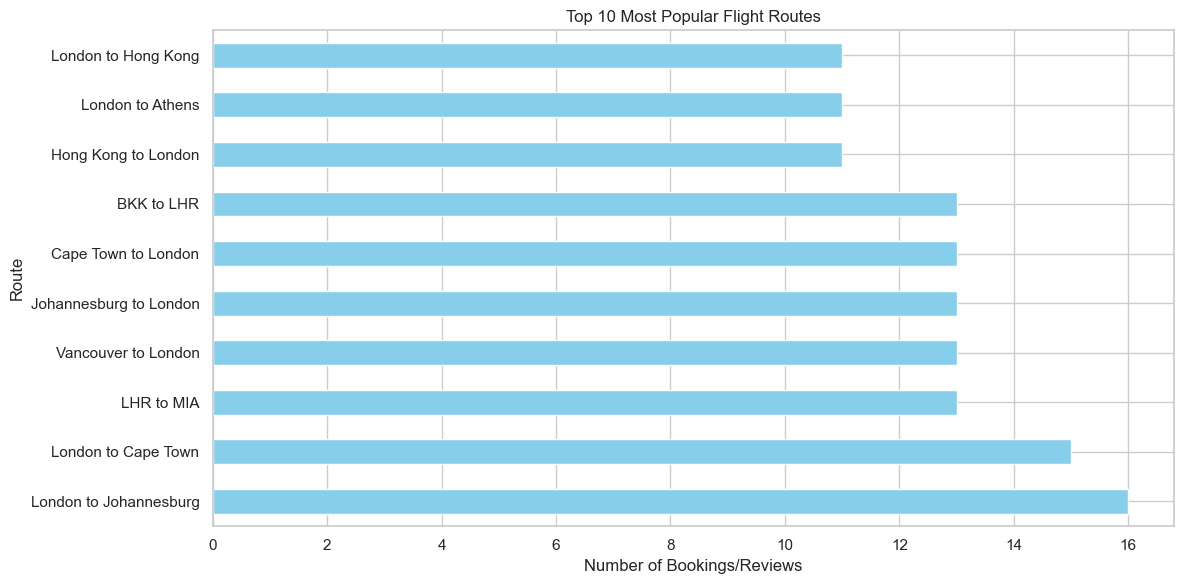

In [46]:
plt.figure(figsize=(12, 6))
top_10_routes.plot(kind='barh', color='skyblue')
plt.xlabel('Number of Bookings/Reviews')
plt.ylabel('Route')
plt.title('Top 10 Most Popular Flight Routes')
plt.tight_layout()
plt.show()

## Project checklist and plan

- Load all datasets from `data/` using relative paths
- Clean and encode relevant columns; handle NaNs
- Add VADER sentiment to `AirlineScrappedReview_Cleaned.csv` and save as `data/AirlineScrappedReview_with_sentiment.csv`
- EDA: Top-10 routes; Flight-hour distribution; Traveller type x Class with ratings
- Modeling: Binary target from Rating (>=5 satisfied); train/test; metrics
- Explainability: SHAP summary; LIME instance explanations
- Inference function for new inputs

We'll fix hardcoded absolute paths and unify IO first.

## EDA: Flight hour distribution

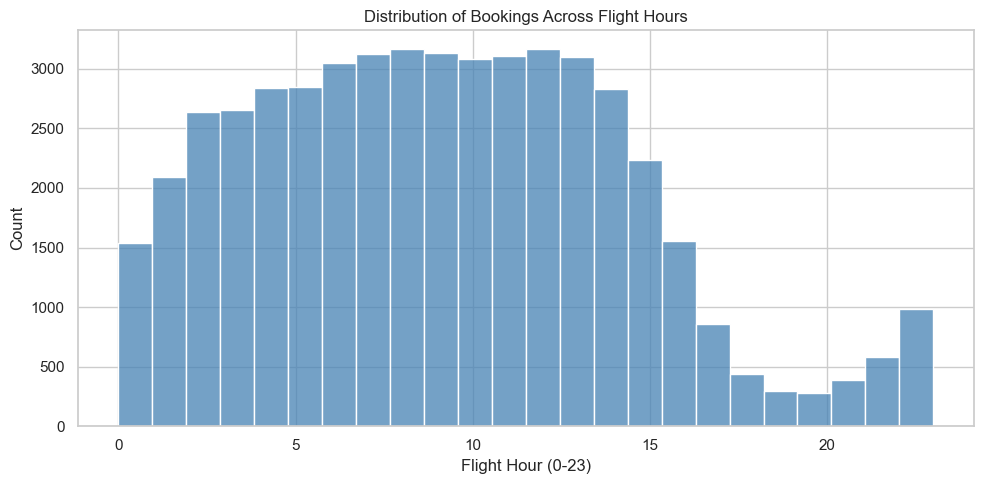

In [47]:
# Distribution of bookings across flight hours
if 'flight_hour' in df2.columns:
    plt.figure(figsize=(10,5))
    sns.histplot(df2['flight_hour'].dropna(), bins=24, kde=False, color='steelblue')
    plt.title('Distribution of Bookings Across Flight Hours')
    plt.xlabel('Flight Hour (0-23)')
    plt.ylabel('Count')
    plt.tight_layout()
    plt.show()
else:
    print("Column 'flight_hour' not found in booking dataset.")

## EDA: Traveler type × Class vs. Rating

Mean Rating by Traveller_Type x Class:


Class,Business Class,Economy Class,First Class,Premium Economy,Unknown
Traveller_Type,,,,,
Business,3.510791,3.457031,4.270270,3.750000,NaN
Couple Leisure,5.332335,3.908297,5.983607,4.239583,NaN
Family Leisure,5.743902,4.061069,4.230769,3.600000,NaN
Solo Leisure,5.780347,4.631193,6.627907,5.653061,1.0
Unknown,5.982935,5.740741,7.127273,5.919540,4.0
Various,NaN,1.000000,NaN,NaN,NaN


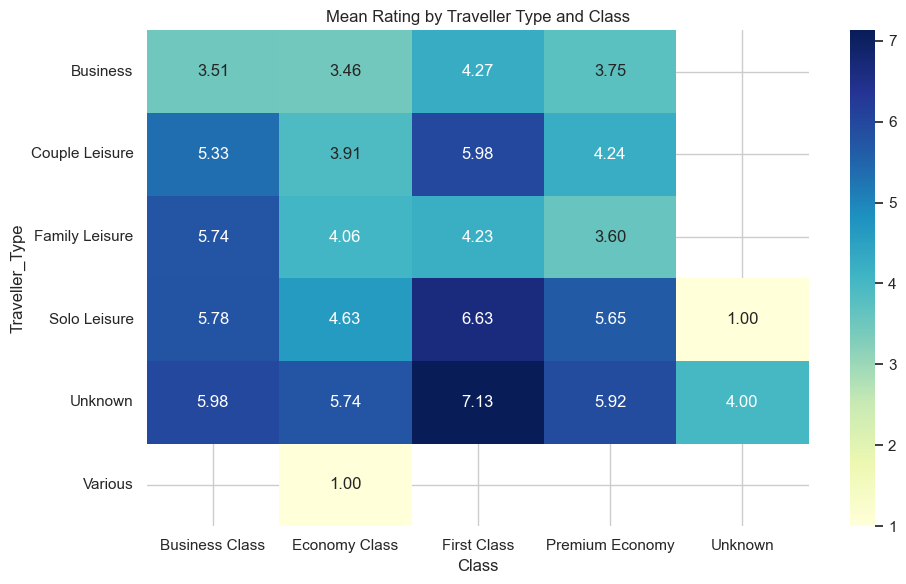


Top 3 combinations by mean rating:
Traveller_Type  Class      
Unknown         First Class    7.127273
Solo Leisure    First Class    6.627907
Couple Leisure  First Class    5.983607
dtype: float64

Bottom 3 combinations by mean rating:
Traveller_Type  Class        
Business        Economy Class    3.457031
Solo Leisure    Unknown          1.000000
Various         Economy Class    1.000000
dtype: float64


In [53]:
# Highest/lowest ratings by Traveller_Type x Class (use correct column name)
if all(col in df4.columns for col in ['Traveller_Type', 'Class', 'Rating']):
    pivot_mean = df4.pivot_table(index='Traveller_Type', columns='Class', values='Rating', aggfunc='mean')
    print("Mean Rating by Traveller_Type x Class:")
    display(pivot_mean)
    
    plt.figure(figsize=(10,6))
    sns.heatmap(pivot_mean, annot=True, fmt='.2f', cmap='YlGnBu')
    plt.title('Mean Rating by Traveller Type and Class')
    plt.tight_layout()
    plt.show()
    
    # Identify highest and lowest combos
    stacked = pivot_mean.stack().sort_values(ascending=False)
    print("\nTop 3 combinations by mean rating:")
    print(stacked.head(3))
    print("\nBottom 3 combinations by mean rating:")
    print(stacked.tail(3))
else:
    print("Required columns not found in reviews dataset.")

## Modeling: Predict passenger satisfaction

### Feature Inspection and Preprocessing Check

In [54]:
# Load sentiment-augmented dataset for modeling
df_model = pd.read_csv(PATH_REVIEWS_WITH_SENT)

print(f"Dataset shape: {df_model.shape}")
print(f"\nColumn names and types:")
print(df_model.dtypes)
print(f"\nSample data:")
display(df_model.head(3))

# Check for missing values in key columns
print(f"\nMissing values in key columns:")
key_cols = ['Traveller_Type', 'Class', 'Verified', 'Rating', 'sentiment_score', 'Review_content', 'Flying_Date']
for col in key_cols:
    if col in df_model.columns:
        missing = df_model[col].isnull().sum()
        print(f"  {col}: {missing} ({missing/len(df_model)*100:.2f}%)")
        
# Check unique values for categorical features
print(f"\nUnique values in categorical columns:")
for col in ['Traveller_Type', 'Class', 'Verified']:
    if col in df_model.columns:
        print(f"\n{col}:")
        print(df_model[col].value_counts())

Dataset shape: (3575, 20)

Column names and types:
Passanger_Name         object
Flying_Date            object
Route                  object
Rating                  int64
Verified               object
Review_title           object
Review_content         object
Traveller_Type         object
Class                  object
Start_Location         object
End_Location           object
Layover_Route          object
Start_Latitude        float64
Start_Longitude       float64
Start_Address          object
End_Latitude          float64
End_Longitude         float64
End_Address            object
sentiment_score       float64
sentiment_category     object
dtype: object

Sample data:


,Passanger_Name,Flying_Date,Route,Rating,Verified,Review_title,Review_content,Traveller_Type,Class,Start_Location,End_Location,Layover_Route,Start_Latitude,Start_Longitude,Start_Address,End_Latitude,End_Longitude,End_Address,sentiment_score,sentiment_category
0,Paige Boet,June 2023,New Orleans to London,1,Trip Verified,The airline lost my luggage,The airline lost my luggage and was absolutely...,Solo Leisure,Economy Class,New Orleans,London,NaN,29.975998,-90.078213,"New Orleans, Orleans Parish, Louisiana, United...",51.507446,-0.127765,"London, Greater London, England, United Kingdom",-0.7990,Negative
1,S Layne,March 2023,London to Amman,1,Trip Verified,fully refunded by our travel insurance,"We booked on the BA website, round trip flight...",Couple Leisure,Business Class,London,Amman,NaN,51.507446,-0.127765,"London, Greater London, England, United Kingdom",31.951569,35.923963,"عمان, ناحية عمان, لواء قصبة عمان, عمان, 11110,...",0.0219,Positive
2,E Lanewoski,NaN,Heathrow to Bodrum,2,Trip Verified,no boarding drinks provided,"First time flying with BA business class, neve...",Solo Leisure,Business Class,London Heathrow,Bodrum,NaN,51.467739,-0.458780,"London Heathrow Airport, The Beacon Roundabout...",37.034399,27.430651,"Bodrum, Muğla, Ege Bölgesi, Türkiye",-0.7096,Negative



Missing values in key columns:
  Traveller_Type: 0 (0.00%)
  Class: 0 (0.00%)
  Verified: 0 (0.00%)
  Rating: 0 (0.00%)
  sentiment_score: 0 (0.00%)
  Review_content: 0 (0.00%)
  Flying_Date: 2620 (73.29%)

Unique values in categorical columns:

Traveller_Type:
Traveller_Type
Couple Leisure    949
Solo Leisure      860
Unknown           760
Business          623
Family Leisure    382
Various             1
Name: count, dtype: int64

Class:
Class
Economy Class      1846
Business Class     1160
Premium Economy     358
First Class         209
Unknown               2
Name: count, dtype: int64

Verified:
Verified
Not Verified     2508
Trip Verified    1067
Name: count, dtype: int64


### Feature Engineering and Target Creation

In [55]:
# Create a working copy
df_prep = df_model.copy()

# 1. Create binary target: satisfied (1) if Rating >= 5, else (0)
df_prep['satisfaction'] = (df_prep['Rating'] >= 5).astype(int)

print("Target distribution:")
print(df_prep['satisfaction'].value_counts())
print(f"\nClass balance: {df_prep['satisfaction'].value_counts(normalize=True)}")

# 2. Feature engineering: extract date features if Flying_Date exists
if 'Flying_Date' in df_prep.columns and df_prep['Flying_Date'].notna().sum() > 0:
    # Parse dates and extract month/year
    df_prep['Flying_Date_parsed'] = pd.to_datetime(df_prep['Flying_Date'], format='%B %Y', errors='coerce')
    df_prep['Flying_Month'] = df_prep['Flying_Date_parsed'].dt.month
    df_prep['Flying_Year'] = df_prep['Flying_Date_parsed'].dt.year
    print(f"\nExtracted date features - Month range: {df_prep['Flying_Month'].min()}-{df_prep['Flying_Month'].max()}")
    print(f"Year range: {df_prep['Flying_Year'].min()}-{df_prep['Flying_Year'].max()}")
else:
    print("\nFlying_Date not available or empty - skipping date features")

# 3. Create text length features
if 'Review_content' in df_prep.columns:
    df_prep['review_length'] = df_prep['Review_content'].fillna('').str.len()
    print(f"\nReview length stats:")
    print(df_prep['review_length'].describe())
    
# 4. Handle sentiment_score missing values (fill with 0 = neutral)
if 'sentiment_score' in df_prep.columns:
    missing_sent = df_prep['sentiment_score'].isnull().sum()
    if missing_sent > 0:
        print(f"\nFilling {missing_sent} missing sentiment_score values with 0 (neutral)")
        df_prep['sentiment_score'] = df_prep['sentiment_score'].fillna(0)

# 5. Clean Verified column - make it binary
if 'Verified' in df_prep.columns:
    print(f"\nOriginal Verified values: {df_prep['Verified'].unique()}")
    df_prep['Verified_binary'] = df_prep['Verified'].apply(lambda x: 1 if 'Trip Verified' in str(x) else 0)
    print(f"Verified_binary distribution:")
    print(df_prep['Verified_binary'].value_counts())

# 6. Drop rows with missing critical features (use correct column name: Traveller_Type)
critical_features = ['Traveller_Type', 'Class', 'sentiment_score', 'Rating']
initial_rows = len(df_prep)
df_prep = df_prep.dropna(subset=critical_features)
print(f"\nDropped {initial_rows - len(df_prep)} rows with missing critical features")
print(f"Final dataset shape: {df_prep.shape}")

Target distribution:
satisfaction
0    1856
1    1719
Name: count, dtype: int64

Class balance: satisfaction
0    0.519161
1    0.480839
Name: proportion, dtype: float64

Extracted date features - Month range: 1.0-12.0
Year range: 2014.0-2023.0

Review length stats:
count    3575.000000
mean      888.153846
std       573.131811
min        83.000000
25%       482.000000
50%       743.000000
75%      1121.000000
max      3534.000000
Name: review_length, dtype: float64

Original Verified values: ['Trip Verified' 'Not Verified']
Verified_binary distribution:
Verified_binary
0    2508
1    1067
Name: count, dtype: int64

Dropped 0 rows with missing critical features
Final dataset shape: (3575, 26)


### Model 1: Random Forest Classifier

In [58]:
# Import ML libraries
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score, 
                             classification_report, confusion_matrix)
import joblib

# Define features for modeling (use correct column name: Traveller_Type)
# Start with core features, add optional ones if available
categorical_features = ['Traveller_Type', 'Class']
numerical_features = ['sentiment_score', 'review_length']

# Add Verified_binary if created
if 'Verified_binary' in df_prep.columns:
    numerical_features.append('Verified_binary')
    
# Add date features if available
if 'Flying_Month' in df_prep.columns and df_prep['Flying_Month'].notna().sum() > 100:
    categorical_features.append('Flying_Month')
if 'Flying_Year' in df_prep.columns and df_prep['Flying_Year'].notna().sum() > 100:
    categorical_features.append('Flying_Year')

all_features = categorical_features + numerical_features
target = 'satisfaction'

print(f"Features for modeling:")
print(f"  Categorical: {categorical_features}")
print(f"  Numerical: {numerical_features}")

# Prepare X and y
X = df_prep[all_features].copy()
y = df_prep[target].copy()

# Handle any remaining NaNs in features
for col in categorical_features:
    if X[col].isnull().sum() > 0:
        X[col] = X[col].fillna('Unknown')
    X[col] = X[col].astype(str)
        
for col in numerical_features:
    if X[col].isnull().sum() > 0:
        X[col] = X[col].fillna(0)

print(f"\nFinal feature matrix shape: {X.shape}")
print(f"Target shape: {y.shape}")

# Train/test split with stratification
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"\nTrain set: {X_train.shape}, Test set: {X_test.shape}")
print(f"Train target distribution:\n{y_train.value_counts(normalize=True)}")
print(f"Test target distribution:\n{y_test.value_counts(normalize=True)}")

Features for modeling:
  Categorical: ['Traveller_Type', 'Class', 'Flying_Month', 'Flying_Year']
  Numerical: ['sentiment_score', 'review_length', 'Verified_binary']

Final feature matrix shape: (3575, 7)
Target shape: (3575,)

Train set: (2860, 7), Test set: (715, 7)
Train target distribution:
satisfaction
0    0.519231
1    0.480769
Name: proportion, dtype: float64
Test target distribution:
satisfaction
0    0.518881
1    0.481119
Name: proportion, dtype: float64


MODEL 1: RANDOM FOREST CLASSIFIER

Training Random Forest...
Training complete!

--- Random Forest Evaluation ---
Accuracy:  0.8294
Precision: 0.8284
Recall:    0.8140
F1-Score:  0.8211

Classification Report:
              precision    recall  f1-score   support

Dissatisfied       0.83      0.84      0.84       371
   Satisfied       0.83      0.81      0.82       344

    accuracy                           0.83       715
   macro avg       0.83      0.83      0.83       715
weighted avg       0.83      0.83      0.83       715

Training complete!

--- Random Forest Evaluation ---
Accuracy:  0.8294
Precision: 0.8284
Recall:    0.8140
F1-Score:  0.8211

Classification Report:
              precision    recall  f1-score   support

Dissatisfied       0.83      0.84      0.84       371
   Satisfied       0.83      0.81      0.82       344

    accuracy                           0.83       715
   macro avg       0.83      0.83      0.83       715
weighted avg       0.83      0.83      0.8

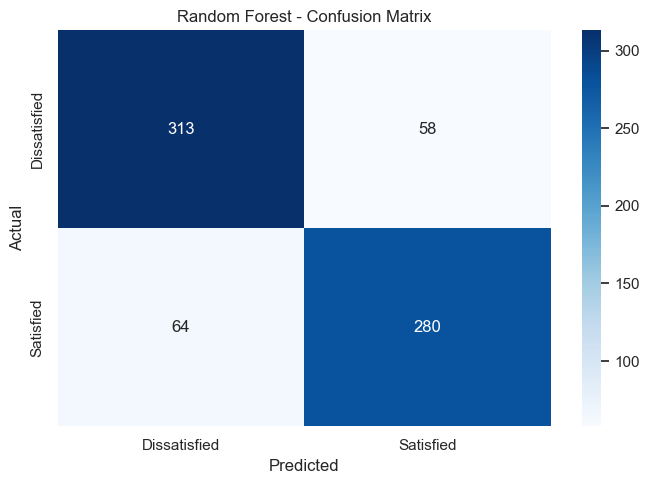


Model saved as 'rf_satisfaction_model.joblib'


In [59]:
# Build Random Forest pipeline
print("=" * 60)
print("MODEL 1: RANDOM FOREST CLASSIFIER")
print("=" * 60)

# Preprocessing pipeline
preprocessor_rf = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_features),
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical_features)
    ])

# Random Forest pipeline
rf_pipeline = Pipeline([
    ('preprocessor', preprocessor_rf),
    ('classifier', RandomForestClassifier(
        n_estimators=100,
        max_depth=15,
        random_state=42,
        class_weight='balanced',
        n_jobs=-1
    ))
])

# Train
print("\nTraining Random Forest...")
rf_pipeline.fit(X_train, y_train)
print("Training complete!")

# Predict
y_pred_rf = rf_pipeline.predict(X_test)
y_pred_proba_rf = rf_pipeline.predict_proba(X_test)

# Evaluate
print("\n--- Random Forest Evaluation ---")
print(f"Accuracy:  {accuracy_score(y_test, y_pred_rf):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_rf):.4f}")
print(f"Recall:    {recall_score(y_test, y_pred_rf):.4f}")
print(f"F1-Score:  {f1_score(y_test, y_pred_rf):.4f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf, target_names=['Dissatisfied', 'Satisfied']))

# Confusion Matrix
cm_rf = confusion_matrix(y_test, y_pred_rf)
plt.figure(figsize=(7, 5))
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Dissatisfied', 'Satisfied'],
            yticklabels=['Dissatisfied', 'Satisfied'])
plt.title('Random Forest - Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

# Save model
joblib.dump(rf_pipeline, 'rf_satisfaction_model.joblib')
print("\nModel saved as 'rf_satisfaction_model.joblib'")

### Model 2: Logistic Regression (Baseline)

MODEL 2: LOGISTIC REGRESSION

Training Logistic Regression...
Training complete!

--- Logistic Regression Evaluation ---
Accuracy:  0.8000
Precision: 0.7680
Recall:    0.8372
F1-Score:  0.8011

Classification Report:
              precision    recall  f1-score   support

Dissatisfied       0.84      0.77      0.80       371
   Satisfied       0.77      0.84      0.80       344

    accuracy                           0.80       715
   macro avg       0.80      0.80      0.80       715
weighted avg       0.80      0.80      0.80       715



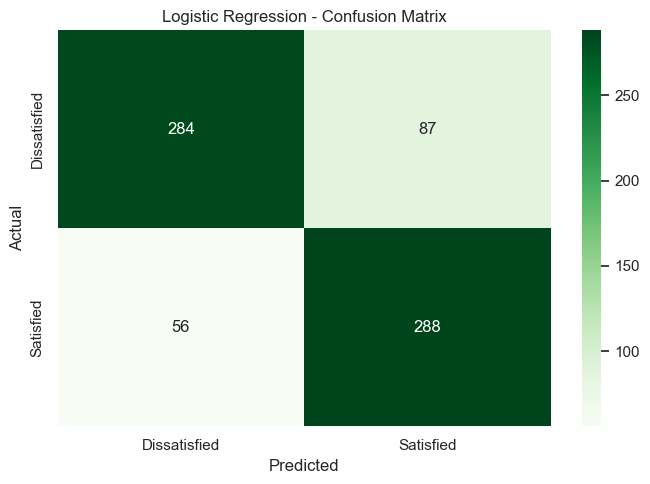


Model saved as 'lr_satisfaction_model.joblib'


In [60]:
# Build Logistic Regression pipeline
print("=" * 60)
print("MODEL 2: LOGISTIC REGRESSION")
print("=" * 60)

# Preprocessing (same as RF)
preprocessor_lr = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_features),
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical_features)
    ])

# Logistic Regression pipeline
lr_pipeline = Pipeline([
    ('preprocessor', preprocessor_lr),
    ('classifier', LogisticRegression(
        max_iter=1000,
        random_state=42,
        class_weight='balanced',
        solver='lbfgs'
    ))
])

# Train
print("\nTraining Logistic Regression...")
lr_pipeline.fit(X_train, y_train)
print("Training complete!")

# Predict
y_pred_lr = lr_pipeline.predict(X_test)
y_pred_proba_lr = lr_pipeline.predict_proba(X_test)

# Evaluate
print("\n--- Logistic Regression Evaluation ---")
print(f"Accuracy:  {accuracy_score(y_test, y_pred_lr):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_lr):.4f}")
print(f"Recall:    {recall_score(y_test, y_pred_lr):.4f}")
print(f"F1-Score:  {f1_score(y_test, y_pred_lr):.4f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred_lr, target_names=['Dissatisfied', 'Satisfied']))

# Confusion Matrix
cm_lr = confusion_matrix(y_test, y_pred_lr)
plt.figure(figsize=(7, 5))
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Greens',
            xticklabels=['Dissatisfied', 'Satisfied'],
            yticklabels=['Dissatisfied', 'Satisfied'])
plt.title('Logistic Regression - Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

# Save model
joblib.dump(lr_pipeline, 'lr_satisfaction_model.joblib')
print("\nModel saved as 'lr_satisfaction_model.joblib'")

### Model 3: Neural Network (Shallow FFNN)

MODEL 3: NEURAL NETWORK (SHALLOW FFNN)

Training Neural Network...
Architecture: Input → 64 → 32 → Output
Training complete!

--- Neural Network Evaluation ---
Accuracy:  0.7986
Precision: 0.7778
Recall:    0.8140
F1-Score:  0.7955

Classification Report:
              precision    recall  f1-score   support

Dissatisfied       0.82      0.78      0.80       371
   Satisfied       0.78      0.81      0.80       344

    accuracy                           0.80       715
   macro avg       0.80      0.80      0.80       715
weighted avg       0.80      0.80      0.80       715

Training complete!

--- Neural Network Evaluation ---
Accuracy:  0.7986
Precision: 0.7778
Recall:    0.8140
F1-Score:  0.7955

Classification Report:
              precision    recall  f1-score   support

Dissatisfied       0.82      0.78      0.80       371
   Satisfied       0.78      0.81      0.80       344

    accuracy                           0.80       715
   macro avg       0.80      0.80      0.80      

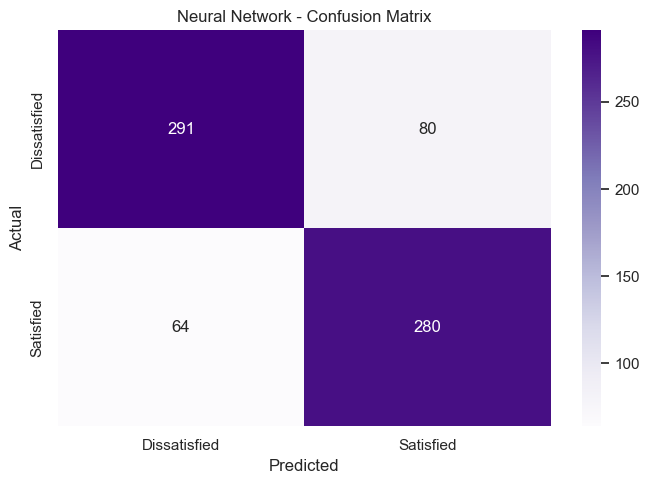


Model saved as 'nn_satisfaction_model.joblib'


In [61]:
# Build Neural Network pipeline
print("=" * 60)
print("MODEL 3: NEURAL NETWORK (SHALLOW FFNN)")
print("=" * 60)

# Preprocessing (same as before)
preprocessor_nn = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_features),
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical_features)
    ])

# Neural Network pipeline
# 2 hidden layers: first with 64 neurons, second with 32
nn_pipeline = Pipeline([
    ('preprocessor', preprocessor_nn),
    ('classifier', MLPClassifier(
        hidden_layer_sizes=(64, 32),
        activation='relu',
        solver='adam',
        alpha=0.0001,
        batch_size='auto',
        learning_rate='adaptive',
        learning_rate_init=0.001,
        max_iter=300,
        random_state=42,
        early_stopping=True,
        validation_fraction=0.1,
        n_iter_no_change=10,
        verbose=False
    ))
])

# Train
print("\nTraining Neural Network...")
print("Architecture: Input → 64 → 32 → Output")
nn_pipeline.fit(X_train, y_train)
print("Training complete!")

# Predict
y_pred_nn = nn_pipeline.predict(X_test)
y_pred_proba_nn = nn_pipeline.predict_proba(X_test)

# Evaluate
print("\n--- Neural Network Evaluation ---")
print(f"Accuracy:  {accuracy_score(y_test, y_pred_nn):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_nn):.4f}")
print(f"Recall:    {recall_score(y_test, y_pred_nn):.4f}")
print(f"F1-Score:  {f1_score(y_test, y_pred_nn):.4f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred_nn, target_names=['Dissatisfied', 'Satisfied']))

# Confusion Matrix
cm_nn = confusion_matrix(y_test, y_pred_nn)
plt.figure(figsize=(7, 5))
sns.heatmap(cm_nn, annot=True, fmt='d', cmap='Purples',
            xticklabels=['Dissatisfied', 'Satisfied'],
            yticklabels=['Dissatisfied', 'Satisfied'])
plt.title('Neural Network - Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

# Save model
joblib.dump(nn_pipeline, 'nn_satisfaction_model.joblib')
print("\nModel saved as 'nn_satisfaction_model.joblib'")

### Model Comparison Summary

MODEL COMPARISON SUMMARY


              Model  Accuracy  Precision  Recall  F1-Score
      Random Forest    0.8294     0.8284  0.8140    0.8211
Logistic Regression    0.8000     0.7680  0.8372    0.8011
     Neural Network    0.7986     0.7778  0.8140    0.7955

BEST MODEL (by F1-Score): Random Forest with F1 = 0.8211


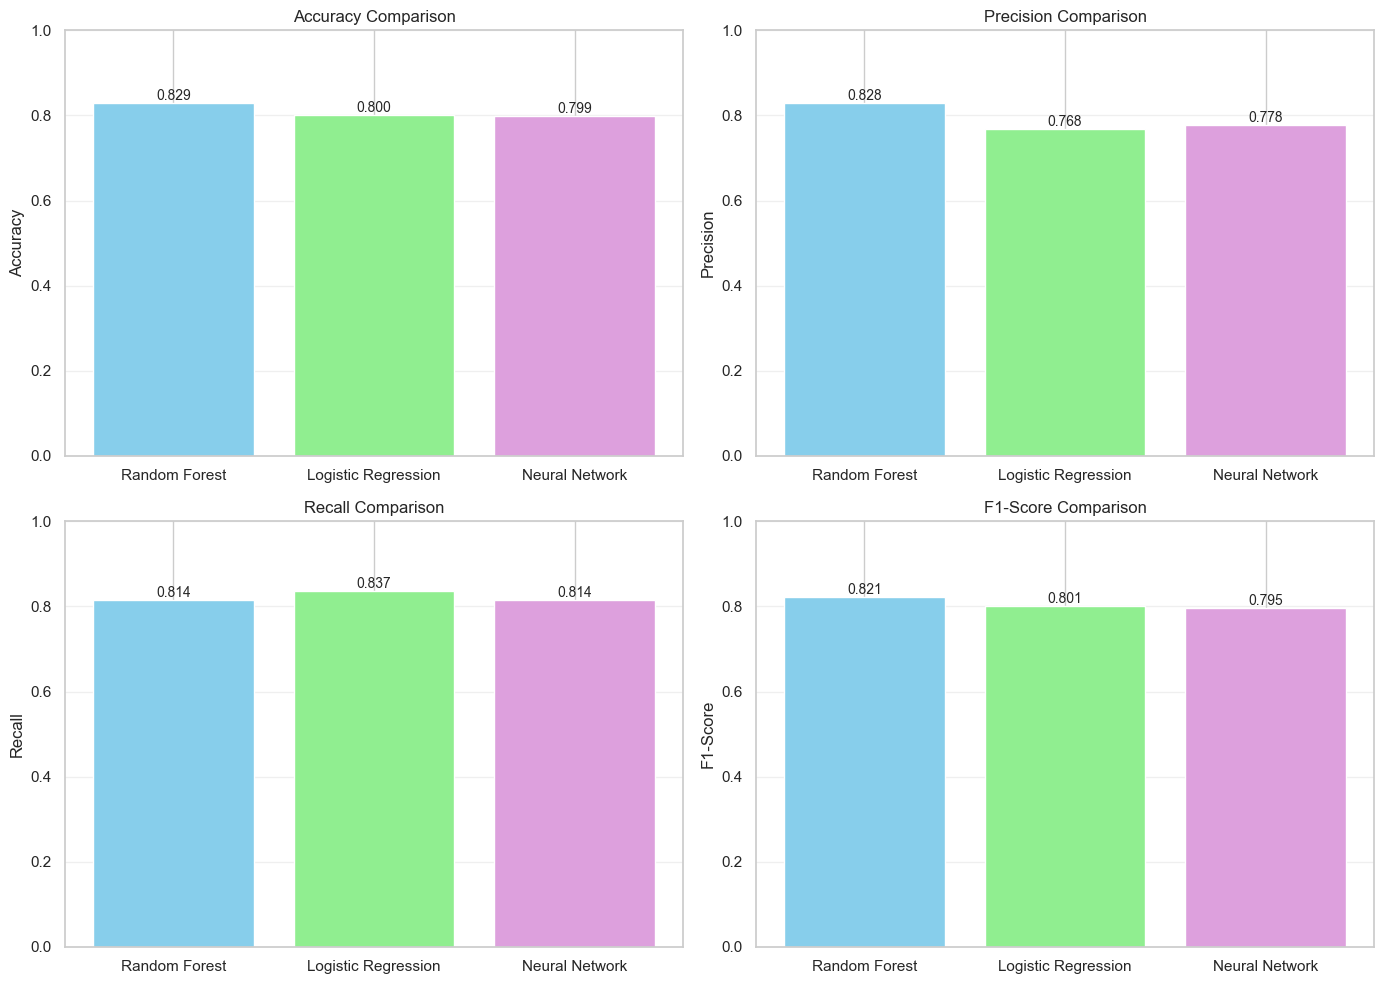


✅ All models trained and evaluated successfully!


In [62]:
# Compare all three models
print("=" * 80)
print("MODEL COMPARISON SUMMARY")
print("=" * 80)

# Create comparison dataframe
comparison_data = {
    'Model': ['Random Forest', 'Logistic Regression', 'Neural Network'],
    'Accuracy': [
        accuracy_score(y_test, y_pred_rf),
        accuracy_score(y_test, y_pred_lr),
        accuracy_score(y_test, y_pred_nn)
    ],
    'Precision': [
        precision_score(y_test, y_pred_rf),
        precision_score(y_test, y_pred_lr),
        precision_score(y_test, y_pred_nn)
    ],
    'Recall': [
        recall_score(y_test, y_pred_rf),
        recall_score(y_test, y_pred_lr),
        recall_score(y_test, y_pred_nn)
    ],
    'F1-Score': [
        f1_score(y_test, y_pred_rf),
        f1_score(y_test, y_pred_lr),
        f1_score(y_test, y_pred_nn)
    ]
}

comparison_df = pd.DataFrame(comparison_data)
comparison_df = comparison_df.round(4)

print("\n")
print(comparison_df.to_string(index=False))

# Determine best model
best_f1_idx = comparison_df['F1-Score'].idxmax()
best_model_name = comparison_df.loc[best_f1_idx, 'Model']
best_f1 = comparison_df.loc[best_f1_idx, 'F1-Score']

print(f"\n{'='*80}")
print(f"BEST MODEL (by F1-Score): {best_model_name} with F1 = {best_f1:.4f}")
print(f"{'='*80}")

# Visualize comparison
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
colors = ['skyblue', 'lightgreen', 'plum']

for idx, metric in enumerate(metrics):
    ax = axes[idx // 2, idx % 2]
    bars = ax.bar(comparison_df['Model'], comparison_df[metric], color=colors)
    ax.set_ylabel(metric)
    ax.set_title(f'{metric} Comparison')
    ax.set_ylim([0, 1])
    ax.grid(axis='y', alpha=0.3)
    
    # Add value labels on bars
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.3f}',
                ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()

print("\n✅ All models trained and evaluated successfully!")